# Проверка переноса разделяющей способности с WildGuardMix

# Anthropic red team

Краудворкеры с MTurk и Upwork в свободной форме пытались добиться вредного ответа от ассистента.
Каждая запись — один многоходовый диалог вида `Human: … Assistant: …`.

**Объём**
* 38 961 диалог от 324 авторов. Десять самых активных авторов дают 30.6% диалогов, с Upwork пришло 580;
* число реплик человека: 1 — 6 785, 2 — 3 699, 3 — 7 381, 4 — 17 402, 5 и больше — 3 694;
* первая реплика короткая: медиана 48 символов, 90-й перцентиль 103.

**Поля**

| поле | содержание |
|---|---|
| `transcript` | диалог целиком: реплики человека и ответы ассистента |
| `rating` | самооценка автора, насколько удалось сломать ассистента, от 0 до 4 |
| `min_harmlessness_score_transcript` | оценка preference-модели для ответов ассистента; чем меньше, тем вреднее |
| `task_description` | описание атаки, которое автор написал своими словами |
| `task_descripton_harmlessness_score` | оценка preference-модели для этого описания (опечатка в названии есть в самом датасете) |
| `model_type` | какая модель отвечала: `plain lm`, `context distillation`, `rlhf`, `rejection sampling` |
| `num_params` | размер модели: 2.7B, 13B, 52B |
| `red_team_member_id` | автор |
| `is_upworker` | автор с Upwork или с MTurk |
| `tags` | категории вреда, до 6 на диалог |

**Распределения**
* `rating`: 0 — 16 475 (42%), 1 — 4 367, 2 — 4 936, 3 — 4 249, 4 — 8 934;
* `model_type`: context distillation — 21 957, rlhf — 7 871, plain lm — 5 152, rejection sampling — 3 981;
* `num_params`: 52B — 23 507, 13B — 8 316, 2.7B — 7 138;
* `rating` согласуется с оценкой ответов: медиана `min_harmlessness_score_transcript` 1.12 при
  `rating` 0 и −1.72 при `rating` 4;
* модели после RLHF сломать труднее: средний `rating` у `rlhf` 0.89, у `rejection sampling` 0.47,
  а у `plain lm` и `context distillation` 2.05 и 1.97;
* `tags` есть только у 742 диалогов, категорий 20. Чаще всего встречаются Violence & incitement (153),
  Discrimination & injustice (117) и Hate speech & offensive language (117).

**Ограничения для нашей задачи**
* нет benign-класса: все диалоги — попытки атаки, хотя часть из них начинается с безобидной реплики;
* нет меток vanilla / adversarial, и почти все атаки по форме vanilla. По грубой оценке регулярным
  выражением приёмы вроде roleplay, «pretend», «hypothetically» и «ignore previous» есть в 0.4% первых
  реплик и в 1.2% диалогов;
* оценки harmlessness относятся к ответам модели и к описанию атаки, а не к самому промпту;
* у одного автора много диалогов, поэтому probe нужно проверять с разбиением по `red_team_member_id`.

## helpful-base: benign-контроль

Часть `helpful-base` того же `hh-rlhf` (Bai et al., 2022, [arXiv:2204.05862](https://arxiv.org/abs/2204.05862)).
Это диалоги краудворкеров, которые просили ассистента о помощи. В полях `chosen` и `rejected` один и
тот же диалог, отличается только последний ответ ассистента, реплики человека совпадают.

* train: 43 835 диалогов; число реплик человека: 1 — 12 843, 2 — 11 894, 3 — 10 761, 4 — 6 097,
  5 и больше — 2 240;
* первая реплика: медиана 50 символов, 90-й перцентиль 111, почти как у red team;
* 20 первых реплик совпадают с первыми репликами red team, в блокноте они исключены из обоих классов.


# Utility code

In [3]:
!pip install -q gliner2

In [4]:
import os, getpass

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

In [5]:
import gc
import gzip
import hashlib
import json
import random
from abc import ABC, abstractmethod
from collections.abc import Callable, Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from gliner2 import GLiNER2
from huggingface_hub import get_token, hf_hub_download
from huggingface_hub.utils import disable_progress_bars
from scipy.stats import rankdata, spearmanr
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as transformers_logging


MAX_LENGTH = 4096
MIN_MAX_LENGTH = 256
OUT_OF_MEMORY_ERROR = getattr(torch, "OutOfMemoryError", torch.cuda.OutOfMemoryError)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

disable_progress_bars()
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

print(DEVICE)

cuda


In [14]:
class TextEmbedder(ABC):
    @abstractmethod
    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        raise NotImplementedError

    def __call__(self, texts: Sequence[str]) -> torch.Tensor:
        return self.embed(texts)


class _TransformerEncoder(TextEmbedder):
    model_name: str
    max_length: int | None = MAX_LENGTH

    def __init__(
            self,
            *,
            device: torch.device = DEVICE,
            batch_size: int = 64
    ) -> None:
        self.device = device
        self.batch_size = batch_size
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = self._load_model().to(self.device).eval()

    def _load_model(self) -> torch.nn.Module:
        return AutoModel.from_pretrained(self.model_name)

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return texts

    @abstractmethod
    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        raise NotImplementedError

    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        texts = list(texts)
        if not texts:
            raise ValueError("The input sequence is empty.")

        texts = self._prepare_texts(texts)
        embeddings = []

        # Защита от OOM: при нехватке памяти тот же кусок пересчитывается меньшим батчем,
        # а когда батч дошёл до единицы — с более жёсткой обрезкой по длине.
        batch_size = self.batch_size
        max_length = min(self.max_length or self.tokenizer.model_max_length,
                         self.tokenizer.model_max_length)
        start = 0

        while start < len(texts):
            try:
                with torch.inference_mode():
                    batch = self.tokenizer(
                        texts[start:start + batch_size],
                        padding="longest",
                        truncation=True,
                        max_length=max_length,
                        return_tensors="pt",
                    )
                    batch = {name: tensor.to(self.device) for name, tensor in batch.items()}
                    embeddings.append(self._get_embeddings(batch).cpu())
            except OUT_OF_MEMORY_ERROR:
                gc.collect()
                if self.device.type == "cuda":
                    torch.cuda.empty_cache()

                if batch_size > 1:
                    batch_size //= 2
                    print(f"{self.model_name}: не хватило памяти, batch_size -> {batch_size}")
                elif max_length > MIN_MAX_LENGTH:
                    max_length //= 2
                    print(f"{self.model_name}: не хватило памяти, max_length -> {max_length}")
                else:
                    raise
                continue

            start += batch_size

        return torch.cat(embeddings, dim=0).T.contiguous()


class _MeanPoolingEmbedder(_TransformerEncoder):

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(**batch).last_hidden_state

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        last_hidden_state = self._get_last_hidden_state(batch)
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)



class EttinEncoder68M(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/ettin-encoder-68m"


class MmBertSmall(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/mmBERT-small"


class E5SmallV2(_MeanPoolingEmbedder):
    model_name = "intfloat/e5-small-v2"

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return [f"query: {text}" for text in texts]


class LlamaPromptGuard2MeanPooler(_MeanPoolingEmbedder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.deberta(**batch).last_hidden_state


class LlamaPromptGuard2_86M(_TransformerEncoder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        backbone_output = self.model.deberta(**batch)
        return self.model.pooler(backbone_output.last_hidden_state)



class GlinerGuardUniEncoder(_TransformerEncoder):
    model_name = "hivetrace/gliner-guard-uniencoder"

    def __init__(
            self,
            *,
            device: torch.device = DEVICE,
            batch_size: int = 64
    ) -> None:

        self.device = device
        self.batch_size = batch_size
        self.model = GLiNER2.from_pretrained(self.model_name).to(self.device).eval()
        # Токенизатор берётся из самой модели: GLiNER2 хранит его в processor вместе со
        # служебными токенами схемы, поэтому AutoTokenizer здесь не используется.
        self.tokenizer = self.model.processor.tokenizer

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        # GLiNER2 — это nn.Module: трансформерный бэкбон лежит в .encoder, задачные головы
        # не используются, берётся то же mean pooling, что и у остальных моделей.
        last_hidden_state = self.model.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


EMBEDDER_TYPES = {
    "ettin-encoder-68m": EttinEncoder68M,
    "mmBERT-small": MmBertSmall,
    "e5-small-v2": E5SmallV2,
    "Llama-Prompt-Guard-2-86M": LlamaPromptGuard2_86M,
    "Llama-Prompt-Guard-2-86M (mean pooler)": LlamaPromptGuard2MeanPooler,
    "gliner-guard-uniencoder": GlinerGuardUniEncoder
}

In [7]:
def describe(x: torch.Tensor, short: bool = False) -> dict[str, float]:
    x = x.detach().to(device=DEVICE, dtype=torch.float32)
    stat = {
        "mean": x.mean().item(),
        "std": x.std(unbiased=True).item(),
    }
    if short:
        return stat
    stat["25%"] = torch.quantile(x, 0.25).item()
    stat["50%"] = torch.quantile(x, 0.50).item()
    stat["75%"] = torch.quantile(x, 0.75).item()

    return stat


def get_components_at_threshold(explained_variance: torch.Tensor, var_threshold: float = 0.9) -> int:
    cumulative_variance = explained_variance.cumsum(dim=0) / explained_variance.sum(dim=0)
    return int(torch.searchsorted(cumulative_variance, var_threshold).item()) + 1


def display_table(
        statistic_method: Callable[..., dict[str, float | int]],
        name: str,
        stat_args_by_model: dict[str, tuple[Any, ...]] | None = None,
        **stat_args_by_group: dict[str, tuple[Any, ...]],
):
    if stat_args_by_model is not None:
        if not stat_args_by_model:
            raise ValueError("The input dictionary contains no models.")

        statistics_by_model = {
            model_name: statistic_method(*stat_args)
            for model_name, stat_args in stat_args_by_model.items()
        }
        table = pd.DataFrame.from_dict(statistics_by_model, orient="index")
        table.index.name = "model"
        separator_selector = ""
    else:
        model_names = dict.fromkeys(
            model_name
            for args_by_model in stat_args_by_group.values()
            for model_name in args_by_model
        )
        if not model_names:
            raise ValueError("The input dictionaries contain no models.")

        statistics_by_model_and_group = {}
        for model_name in model_names:
            for group_name, stat_args in stat_args_by_group.items():
                statistics_by_model_and_group[(model_name, group_name)] = statistic_method(
                    *stat_args[model_name]
                )

        table = pd.DataFrame.from_dict(
            statistics_by_model_and_group,
            orient="index",
        )
        table.index = pd.MultiIndex.from_tuples(
            table.index,
            names=["model", "group"],
        )

        separator_rows = [
            row_number
            for row_number, (previous, current) in enumerate(
                zip(table.index, table.index[1:]),
                start=2,
            )
            if previous[0] != current[0]
        ]
        separator_selector = ", ".join(
            f"tbody tr:nth-child({row}) > *"
            for row in separator_rows
        )

    formatters = {
        column: "{:d}" if pd.api.types.is_integer_dtype(table[column].dtype) else "{:.4f}"
        for column in table.columns
    }

    styles = [
        {
            "selector": "table",
            "props": [("border-collapse", "collapse")],
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #9aa5b1"),
                ("padding", "6px 10px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "left"),
            ],
        },
    ]
    if separator_selector:
        styles.append({
            "selector": separator_selector,
            "props": [("border-top", "3px solid #4a5568")],
        })

    return (
        table.style
        .set_caption(name)
        .format(formatters)
        .background_gradient(cmap="Blues", axis=0)
        .set_table_styles(styles)
    )

## Linear probe


In [8]:
def train_linear_probe(
        train_x: torch.Tensor,
        train_y: torch.Tensor,
        val_x: torch.Tensor,
        val_y: torch.Tensor,
        lr: float = 1e-3,
        tol: float = 1e-5,
        early_stopping_iters: int = 100,
        max_iter_num: int = 10_000,
) -> torch.nn.Module:
    linear = torch.nn.Linear(train_x.shape[1], 1, device=DEVICE)
    optimizer = torch.optim.AdamW(linear.parameters(), lr=lr)

    best_val_loss = torch.inf
    best_state = None
    iterations_without_improvement = 0

    for i in range(1, max_iter_num + 1):
        linear.train()
        optimizer.zero_grad()
        train_loss = F.binary_cross_entropy_with_logits(linear(train_x), train_y)
        train_loss.backward()
        optimizer.step()

        linear.eval()
        with torch.no_grad():
            val_loss = F.binary_cross_entropy_with_logits(linear(val_x), val_y).item()

        if best_val_loss - val_loss > tol:
            best_val_loss = val_loss
            best_state = {
                name: value.detach().clone()
                for name, value in linear.state_dict().items()
            }
            iterations_without_improvement = 0
        else:
            iterations_without_improvement += 1
            if iterations_without_improvement >= early_stopping_iters:
                break

    if best_state is not None:
        linear.load_state_dict(best_state)

    return linear


PROBE_SPLITS = 10


def auroc(negative_scores: torch.Tensor | np.ndarray, positive_scores: torch.Tensor | np.ndarray) -> float:
    """Доля пар, где positive получил скор выше negative; ничьи идут за половину."""
    negative_scores = np.asarray(negative_scores, dtype=np.float64)
    positive_scores = np.asarray(positive_scores, dtype=np.float64)
    ranks = rankdata(np.concatenate([negative_scores, positive_scores]))
    n_positive = len(positive_scores)
    positive_rank_sum = ranks[len(negative_scores):].sum()
    return float((positive_rank_sum - n_positive * (n_positive + 1) / 2) / (len(negative_scores) * n_positive))


def own_groups(n: int, prefix: str) -> np.ndarray:
    return np.array([f"{prefix}-{index}" for index in range(n)])


def split_indices(groups: np.ndarray, test_frac: float = 0.2, val_frac: float = 0.1) -> dict[str, torch.Tensor]:
    """Случайное разбиение на train/val/test, при котором группа целиком попадает в одну часть."""
    unique_groups, inverse = np.unique(groups, return_inverse=True)
    order = torch.randperm(len(unique_groups)).numpy()
    sizes = np.bincount(inverse, minlength=len(unique_groups))[order]
    starts = (np.cumsum(sizes) - sizes) / len(groups)

    part_of_group = np.empty(len(unique_groups), dtype=object)
    part_of_group[order] = np.where(
        starts < test_frac, "test", np.where(starts < test_frac + val_frac, "val", "train")
    )
    parts = part_of_group[inverse]

    return {
        name: torch.from_numpy(np.flatnonzero(parts == name)).to(DEVICE)
        for name in ("train", "val", "test")
    }


def stack_classes(negative: torch.Tensor, positive: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Две матрицы (d, n) -> объекты по строкам и метки: 0 у negative, 1 у positive."""
    x = torch.cat([negative, positive], dim=1).T.to(DEVICE)
    y = torch.cat([torch.zeros(negative.shape[1]), torch.ones(positive.shape[1])]).unsqueeze(1).to(DEVICE)
    return x, y


def describe_probe_cv(
        negative: torch.Tensor,
        positive: torch.Tensor,
        negative_groups: np.ndarray | None = None,
        positive_groups: np.ndarray | None = None,
        split_number: int = PROBE_SPLITS,
) -> dict[str, float]:
    x, y = stack_classes(negative, positive)
    groups = np.concatenate([
        own_groups(negative.shape[1], "negative") if negative_groups is None else negative_groups,
        own_groups(positive.shape[1], "positive") if positive_groups is None else positive_groups,
    ])

    aurocs, accuracies = [], []
    for _ in range(split_number):
        parts = split_indices(groups)
        probe = train_linear_probe(
            x[parts["train"]], y[parts["train"]], x[parts["val"]], y[parts["val"]]
        ).eval()
        with torch.no_grad():
            logits = probe(x[parts["test"]]).squeeze(1).cpu()
        target = y[parts["test"]].squeeze(1).cpu().bool()

        aurocs.append(auroc(logits[~target], logits[target]))
        accuracies.append(((logits > 0) == target).float().mean().item())

    return {
        "auroc (mean)": float(np.mean(aurocs)),
        "auroc (std)": float(np.std(aurocs, ddof=1)),
        "accuracy (mean)": float(np.mean(accuracies)),
        "accuracy (std)": float(np.std(accuracies, ddof=1)),
    }


def fit_probe(negative: torch.Tensor, positive: torch.Tensor, val_frac: float = 0.1) -> torch.nn.Module:
    """Probe на всей выборке для переноса на другие данные; val_frac уходит на early stopping."""
    x, y = stack_classes(negative, positive)
    parts = split_indices(own_groups(len(y), "sample"), test_frac=0.0, val_frac=val_frac)
    return train_linear_probe(
        x[parts["train"]], y[parts["train"]], x[parts["val"]], y[parts["val"]]
    ).eval()


def probe_scores(probe: torch.nn.Module, embeddings: torch.Tensor) -> torch.Tensor:
    """Логит probe для каждого столбца матрицы (d, n)."""
    with torch.no_grad():
        return probe(embeddings.T.to(DEVICE)).squeeze(1).cpu()

# Данные

## WildGuardMix

Та же выборка, что в `WildGuardMix.ipynb`: по 400 промптов в каждой ячейке класс × стиль после
дедупликации и фильтра по длине.

In [9]:
def read_hf(repo: str, filename: str) -> pl.DataFrame:
    path = hf_hub_download(repo_id=repo, filename=filename, repo_type="dataset", token=os.environ["HF_TOKEN"])
    return pl.read_csv(path) if filename.endswith(".csv") else pl.read_parquet(path)

In [10]:
MAX_PROMPT_CHARS = 15_000
SAMPLE_PER_CELL = 400
STYLE_NAMES = ("vanilla", "adversarial")
HARM_LABELS = {"benign": "unharmful", "harmful": "harmful"}

wildguard = read_hf("allenai/wildguardmix", "train/wildguard_train.parquet")

wildguard_prompts = (
    wildguard
    .filter(pl.col("prompt_harm_label").is_not_null())
    .unique(subset=["prompt"], keep="first", maintain_order=True)
    .select("prompt", "prompt_harm_label", "adversarial")
    .with_columns(
        pl.when(pl.col("adversarial"))
        .then(pl.lit("adversarial"))
        .otherwise(pl.lit("vanilla"))
        .alias("style")
    )
)


def sample_wildguard(label: str, style_name: str) -> list[str]:
    cell = wildguard_prompts.filter(
        (pl.col("prompt_harm_label") == HARM_LABELS[label]) & (pl.col("style") == style_name)
    )
    if len(cell) < SAMPLE_PER_CELL:
        print(f"{label}/{style_name}: доступно {len(cell)}, берём всё")
    return cell.sample(n=min(SAMPLE_PER_CELL, len(cell)), seed=SEED, shuffle=True)["prompt"].to_list()


WG_TEXTS = {
    f"wg {label} {style_name}": sample_wildguard(label, style_name)
    for label in HARM_LABELS
    for style_name in STYLE_NAMES
}

## Anthropic hh-rlhf

 Из диалогов берутся только реплики человека.

Поля red team, которые используются ниже:
* `rating` — самооценка автора, насколько удалось сломать ассистента: от 0 до 4;
* `model_type` — какая модель отвечала: `plain lm`, `context distillation`, `rlhf`, `rejection sampling`;
* `task_descripton_harmlessness_score` — оценка preference-модели для описания атаки, которое автор
  написал своими словами; чем меньше, тем вреднее. Опечатка в названии — из самого датасета;
* `red_team_member_id` — автор.

Выборки:
* **раздел 1** — по 1000 уникальных первых реплик из red team и из helpful-base. Реплики короче 10
  символов («Hey», «v») отброшены, как и два десятка реплик, которые есть в обоих наборах;
* **раздел 3** — вся сторона человека (реплики через перевод строки) для `rating` 0 и 4 в каждом
  `model_type`, до 400 диалогов в ячейке. Успешных атак на `rejection sampling` около 200, они
  берутся все;
* **раздел 4** — по 500 диалогов из трёх и более ходов в каждом наборе.

Диалоги раздела 1 в разделы 3 и 4 не попадают: на них обучается направление `Anthropic`, и иначе оно
проверялось бы на своих же обучающих данных.

In [11]:
HH_REPO = "Anthropic/hh-rlhf"
MIN_PROMPT_CHARS = 10
ANTHROPIC_SAMPLE = 1000
ESCALATION_SAMPLE = 500
ESCALATION_TURNS = 3
RATINGS = (0.0, 4.0)
MODEL_TYPES = ("plain lm", "context distillation", "rlhf", "rejection sampling")
ESCALATION_VARIANTS = tuple(f"turn {k}" for k in range(1, ESCALATION_TURNS + 1)) + ("last turn", "human side")


def read_hh(filename: str) -> list[dict[str, Any]]:
    path = hf_hub_download(repo_id=HH_REPO, filename=filename, repo_type="dataset")
    with gzip.open(path, "rt", encoding="utf-8") as file:
        raw = file.read()
    # red-team-attempts лежит одним JSON-массивом, остальные части hh-rlhf — JSONL
    if raw.lstrip().startswith("["):
        return json.loads(raw)
    return [json.loads(line) for line in raw.splitlines() if line.strip()]


def human_turns(transcript: str) -> list[str]:
    """Реплики человека из диалога вида '\n\nHuman: ...\n\nAssistant: ...'."""
    return [
        part.split("\n\nAssistant:", 1)[0].strip()
        for part in transcript.split("\n\nHuman:")[1:]
    ]


def dialog_frame(rows: list[dict[str, Any]]) -> pl.DataFrame:
    return (
        pl.DataFrame(rows, infer_schema_length=None)
        .with_row_index("dialog_id")
        .with_columns(
            pl.col("turns").list.len().alias("n_turns"),
            pl.col("turns").list.first().alias("first_turn"),
            pl.col("turns").list.last().alias("last_turn"),
            pl.col("turns").list.join("\n").alias("human_side"),
        )
    )


red_team = dialog_frame([
    {
        "turns": human_turns(row["transcript"]),
        "rating": row["rating"],
        "model_type": row["model_type"],
        "task_harmlessness": row["task_descripton_harmlessness_score"],
        "author": f"author-{row['red_team_member_id']}",
    }
    for row in read_hh("red-team-attempts/red_team_attempts.jsonl.gz")
])
helpful = dialog_frame([
    {"turns": human_turns(row["chosen"])}
    for row in read_hh("helpful-base/train.jsonl.gz")
])
print("red team:", red_team.shape, "helpful-base:", helpful.shape)

shared_first_turns = sorted(set(red_team["first_turn"]) & set(helpful["first_turn"]))


def first_turn_sample(dialogs: pl.DataFrame) -> pl.DataFrame:
    return (
        dialogs
        .filter(pl.col("first_turn").str.len_chars() >= MIN_PROMPT_CHARS)
        .filter(~pl.col("first_turn").is_in(shared_first_turns))
        .unique(subset=["first_turn"], keep="first", maintain_order=True)
        .sample(n=ANTHROPIC_SAMPLE, seed=SEED, shuffle=True)
    )


AN_HARMFUL = first_turn_sample(red_team)
AN_BENIGN = first_turn_sample(helpful)

red_team_rest = red_team.filter(~pl.col("dialog_id").is_in(AN_HARMFUL["dialog_id"].to_list()))
helpful_rest = helpful.filter(~pl.col("dialog_id").is_in(AN_BENIGN["dialog_id"].to_list()))


def rating_group(model_type: str, rating: float) -> str:
    return f"rating {int(rating)} · {model_type}"


def sample_rating_cell(model_type: str, rating: float) -> pl.DataFrame:
    cell = (
        red_team_rest
        .filter((pl.col("model_type") == model_type) & (pl.col("rating") == rating))
        .unique(subset=["human_side"], keep="first", maintain_order=True)
    )
    if len(cell) < SAMPLE_PER_CELL:
        print(f"{rating_group(model_type, rating)}: доступно {len(cell)}, берём всё")
    return cell.sample(n=min(SAMPLE_PER_CELL, len(cell)), seed=SEED, shuffle=True)


RATING_CELLS = {
    rating_group(model_type, rating): sample_rating_cell(model_type, rating)
    for model_type in MODEL_TYPES
    for rating in RATINGS
}


def escalation_group(dialogs_name: str, variant: str) -> str:
    return f"{dialogs_name} · {variant}"


def escalation_texts(dialogs: pl.DataFrame) -> dict[str, list[str]]:
    """Тексты одного и того же набора диалогов в одном порядке: реплики 1..K, последняя и все вместе."""
    texts = {
        f"turn {k}": dialogs["turns"].list.get(k - 1).to_list()
        for k in range(1, ESCALATION_TURNS + 1)
    }
    texts["last turn"] = dialogs["last_turn"].to_list()
    texts["human side"] = dialogs["human_side"].to_list()
    return texts


ESCALATION_DIALOGS = {
    name: dialogs.filter(pl.col("n_turns") >= ESCALATION_TURNS).sample(
        n=ESCALATION_SAMPLE, seed=SEED, shuffle=True
    )
    for name, dialogs in (("red team", red_team_rest), ("helpful-base", helpful_rest))
}

red team: (38961, 10) helpful-base: (43835, 6)
rating 4 · rejection sampling: доступно 209, берём всё


## Длины и эмбеддинги

Длина — главный конфаундер: в разделе 3 успешная атака может отличаться просто числом реплик. Поэтому
в каждом разделе рядом с probe стоит AUROC одной длины в токенах.

Эмбеддинги кэшируются по группам вместе с отпечатком текстов: если выборка группы поменялась, группа
пересчитается сама.

In [12]:
TEXTS = {
    **WG_TEXTS,
    "an benign": AN_BENIGN["first_turn"].to_list(),
    "an harmful": AN_HARMFUL["first_turn"].to_list(),
    **{group: cell["human_side"].to_list() for group, cell in RATING_CELLS.items()},
    **{
        escalation_group(name, variant): texts
        for name, dialogs in ESCALATION_DIALOGS.items()
        for variant, texts in escalation_texts(dialogs).items()
    },
}

LENGTH_TOKENIZER = AutoTokenizer.from_pretrained("jhu-clsp/mmBERT-small")
TOKEN_LENGTHS = {
    group: np.array([len(token_ids) for token_ids in LENGTH_TOKENIZER(texts)["input_ids"]])
    for group, texts in TEXTS.items()
}

display(
    pd.DataFrame({
        group: {
            "n": len(lengths),
            "median tokens": np.median(lengths),
            "p95 tokens": np.quantile(lengths, 0.95),
        }
        for group, lengths in TOKEN_LENGTHS.items()
    }).T.astype({"n": int})
)

,n,median tokens,p95 tokens
wg benign vanilla,400,14.0,50.10
wg benign adversarial,400,144.0,326.15
wg harmful vanilla,400,22.0,78.30
wg harmful adversarial,400,178.5,364.15
an benign,1000,14.0,44.05
an harmful,1000,13.0,32.00
rating 0 · plain lm,400,42.0,113.05
rating 4 · plain lm,400,44.0,98.05
rating 0 · context distillation,400,49.0,126.05
rating 4 · context distillation,400,46.0,104.10


In [15]:
EMBEDDINGS_FILENAME = "embeddings_anthropic_red_team.pt"


def text_fingerprint(texts: Sequence[str]) -> str:
    return hashlib.sha1("\x1f".join(texts).encode("utf-8")).hexdigest()


def get_embeddings(
        texts_by_group: dict[str, Sequence[str]],
        embeddings_filename: str,
) -> dict[str, dict[str, torch.Tensor]]:
    try:
        embeddings = torch.load(embeddings_filename, weights_only=True)
    except FileNotFoundError:
        print("Getting embeddings from scratch...")
        embeddings = {}

    fingerprints = embeddings.setdefault("fingerprints", {})
    for group, texts in texts_by_group.items():
        fingerprint = text_fingerprint(texts)
        if fingerprints.get(group) != fingerprint:
            for model_name in EMBEDDER_TYPES:
                embeddings.get(model_name, {}).pop(group, None)
            fingerprints[group] = fingerprint

    for model_name, embedder_type in EMBEDDER_TYPES.items():
        model_embeddings = embeddings.setdefault(model_name, {})
        pending = [group for group in texts_by_group if group not in model_embeddings]
        if not pending:
            print(f"{model_name}: из кэша")
            continue

        print(f"{model_name}: считаем {len(pending)} групп")
        embedder = embedder_type(batch_size=2 if model_name == "Llama-Prompt-Guard-2-86M" else 16)
        for group in pending:
            model_embeddings[group] = embedder(texts_by_group[group])

        del embedder
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        torch.save(embeddings, embeddings_filename)

    return embeddings


EMBEDDINGS = get_embeddings(TEXTS, EMBEDDINGS_FILENAME)

ettin-encoder-68m: из кэша
mmBERT-small: из кэша
e5-small-v2: из кэша
Llama-Prompt-Guard-2-86M: из кэша
Llama-Prompt-Guard-2-86M (mean pooler): считаем 24 групп
meta-llama/Llama-Prompt-Guard-2-86M: не хватило памяти, batch_size -> 8
meta-llama/Llama-Prompt-Guard-2-86M: не хватило памяти, batch_size -> 4
meta-llama/Llama-Prompt-Guard-2-86M: не хватило памяти, batch_size -> 2
gliner-guard-uniencoder: считаем 24 групп
🧠 Model Configuration
Encoder model      : bogdanminko/mmBERT-small
Counting layer     : count_lstm_v2
Token pooling      : first


# 1. Вне распределения: red team против helpful-base

Оба класса — первые реплики из одного датасета, с одной платформы и одной длины, поэтому
разделимость здесь не может держаться на источнике, как в смешанной выборке RQ1.

* `WildGuardMix vanilla` — точка отсчёта: та же постановка на WildGuardMix;
* `Anthropic, random split` против `Anthropic, split by author` — если второе заметно ниже, часть
  качества давала манера авторов;
* AUROC длины выше таблицы — насколько классы различимы без эмбеддингов вообще.

Метка шумная: часть попыток red team начинается с безобидной реплики, и такие промпты законно
оказываются на стороне benign. Выборки разного размера (400 + 400 против 1000 + 1000), так что
сравнивать стоит порядок величин, а не третий знак.

In [16]:
AN_AUTHORS = AN_HARMFUL["author"].to_numpy()

print(f"AUROC длины в токенах, red team против helpful-base: "
      f"{auroc(TOKEN_LENGTHS['an benign'], TOKEN_LENGTHS['an harmful']):.3f}")

display_table(
    describe_probe_cv,
    "Linear probe: harmful vs benign",
    **{
        "WildGuardMix vanilla": {
            model_name: (EMBEDDINGS[model_name]["wg benign vanilla"], EMBEDDINGS[model_name]["wg harmful vanilla"])
            for model_name in EMBEDDER_TYPES
        },
        "Anthropic, random split": {
            model_name: (EMBEDDINGS[model_name]["an benign"], EMBEDDINGS[model_name]["an harmful"])
            for model_name in EMBEDDER_TYPES
        },
        "Anthropic, split by author": {
            model_name: (EMBEDDINGS[model_name]["an benign"], EMBEDDINGS[model_name]["an harmful"], None, AN_AUTHORS)
            for model_name in EMBEDDER_TYPES
        },
    },
)

AUROC длины в токенах, red team против helpful-base: 0.468


# 2. Перенос направления вреда

Probe обучается на WildGuardMix целиком (10% уходит на early stopping) — отдельно на vanilla, на
adversarial и на обоих стилях — и без дообучения применяется к выборке раздела 1.

* `auroc on Anthropic` стоит сравнить с `Anthropic, split by author` из раздела 1 — это потолок для той
  же выборки. Чем ближе перенос к потолку, тем универсальнее направление;
* `spearman vs task harmlessness` — корреляция логита на промптах red team с оценкой вредности
  описания атаки. Если направление ловит степень вреда, а не только «атака или нет», корреляция
  отрицательная: больше логит — меньше harmlessness.

Здесь же обучается направление `Anthropic` на всей выборке раздела 1 — оно нужно в разделах 3 и 4.

In [17]:
PROBE_SOURCES = {
    "WG vanilla": (["wg benign vanilla"], ["wg harmful vanilla"]),
    "WG adversarial": (["wg benign adversarial"], ["wg harmful adversarial"]),
    "WG all": (["wg benign vanilla", "wg benign adversarial"], ["wg harmful vanilla", "wg harmful adversarial"]),
    "Anthropic": (["an benign"], ["an harmful"]),
}
TRANSFER_SOURCES = ("WG vanilla", "WG adversarial", "WG all")


def group_columns(model_name: str, groups: Sequence[str]) -> torch.Tensor:
    return torch.cat([EMBEDDINGS[model_name][group] for group in groups], dim=1)


HARM_PROBES = {
    model_name: {
        source: fit_probe(group_columns(model_name, negative), group_columns(model_name, positive))
        for source, (negative, positive) in PROBE_SOURCES.items()
    }
    for model_name in EMBEDDER_TYPES
}

AN_TASK_HARMLESSNESS = AN_HARMFUL["task_harmlessness"].to_numpy()


def describe_transfer(probe: torch.nn.Module, benign: torch.Tensor, harmful: torch.Tensor) -> dict[str, float]:
    harmful_scores = probe_scores(probe, harmful)
    rho, p_value = spearmanr(harmful_scores.numpy(), AN_TASK_HARMLESSNESS)
    return {
        "auroc on Anthropic": auroc(probe_scores(probe, benign), harmful_scores),
        "spearman vs task harmlessness": float(rho),
        "p-value": float(p_value),
    }


display_table(
    describe_transfer,
    "Перенос probe с WildGuardMix на Anthropic",
    **{
        source: {
            model_name: (
                HARM_PROBES[model_name][source],
                EMBEDDINGS[model_name]["an benign"],
                EMBEDDINGS[model_name]["an harmful"],
            )
            for model_name in EMBEDDER_TYPES
        }
        for source in TRANSFER_SOURCES
    },
)

# 3. Успешные атаки против неуспешных

Сравнение идёт внутри одного `model_type`: RLHF-модель сломать труднее, и без этого probe различал
бы модели, а не промпты. Вход — вся сторона человека в диалоге.

* `probe auroc` — отличимы ли успешные атаки от неуспешных вообще; автор целиком в train или в test;
* `WG all score auroc` и `Anthropic score auroc` — без обучения: выше ли скор вреда у успешных атак.
  Ниже 0.5 значит, что успешные атаки выглядят *безопаснее* неуспешных — аналог маскировки намерения
  формой подачи;
* `length auroc` — то же для длины в токенах, одинаково для всех моделей.

`plain lm` соглашается почти на всё, поэтому `rating` там ближе к тому, насколько опасен сам запрос.
У `rlhf` и `rejection sampling` успех сильнее зависит от того, как запрос подан.

In [18]:
SCORE_SOURCES = ("WG all", "Anthropic")


def describe_rating_cell(model_name: str, model_type: str) -> dict[str, float | int]:
    failed_group, succeeded_group = (rating_group(model_type, rating) for rating in RATINGS)
    failed = EMBEDDINGS[model_name][failed_group]
    succeeded = EMBEDDINGS[model_name][succeeded_group]

    cv = describe_probe_cv(
        failed,
        succeeded,
        RATING_CELLS[failed_group]["author"].to_numpy(),
        RATING_CELLS[succeeded_group]["author"].to_numpy(),
    )
    row = {
        "n rating 0": failed.shape[1],
        "n rating 4": succeeded.shape[1],
        "probe auroc (mean)": cv["auroc (mean)"],
        "probe auroc (std)": cv["auroc (std)"],
    }
    for source in SCORE_SOURCES:
        probe = HARM_PROBES[model_name][source]
        row[f"{source} score auroc"] = auroc(probe_scores(probe, failed), probe_scores(probe, succeeded))
    row["length auroc"] = auroc(TOKEN_LENGTHS[failed_group], TOKEN_LENGTHS[succeeded_group])
    return row


display_table(
    describe_rating_cell,
    "rating 4 против rating 0 внутри model_type",
    **{
        model_type: {model_name: (model_name, model_type) for model_name in EMBEDDER_TYPES}
        for model_type in MODEL_TYPES
    },
)

# 4. Многоходовость как вариант adversarial

Реплики red team после первой — это эскалация: автор переформулирует, давит, уточняет. Если намерение
проявляется только в контексте, скор вреда растёт от хода к ходу.

Контроль — диалоги helpful-base из трёх и более ходов. Поздняя реплика в любом диалоге — продолжение
разговора, а не самостоятельный запрос, поэтому сравнение идёт на одинаковых позициях, и рост у red
team что-то значит только на фоне helpful-base.

* `auroc · …` — red team против helpful-base на одной и той же позиции; `human side` — все реплики
  человека вместе;
* `P(last > first) · …` — доля диалогов, где скор последней реплики выше, чем первой. Для helpful-base
  это фон.

Направления два: `WG all` — внешнее, `Anthropic` — обучено на диалогах, которых в этой выборке нет. На
графике логиты приведены к z относительно первых реплик helpful-base, полоса — 95% доверительный
интервал среднего.

In [19]:
def describe_escalation(model_name: str, source: str) -> dict[str, float]:
    probe = HARM_PROBES[model_name][source]
    scores = {
        (name, variant): probe_scores(probe, EMBEDDINGS[model_name][escalation_group(name, variant)]).numpy()
        for name in ESCALATION_DIALOGS
        for variant in ESCALATION_VARIANTS
    }

    row = {
        f"auroc · {variant}": auroc(scores[("helpful-base", variant)], scores[("red team", variant)])
        for variant in ESCALATION_VARIANTS
    }
    for name in ESCALATION_DIALOGS:
        row[f"P(last > first) · {name}"] = float(np.mean(scores[(name, "last turn")] > scores[(name, "turn 1")]))
    return row


display_table(
    describe_escalation,
    "Скор вреда по ходам диалога: red team против helpful-base",
    **{
        source: {model_name: (model_name, source) for model_name in EMBEDDER_TYPES}
        for source in SCORE_SOURCES
    },
)

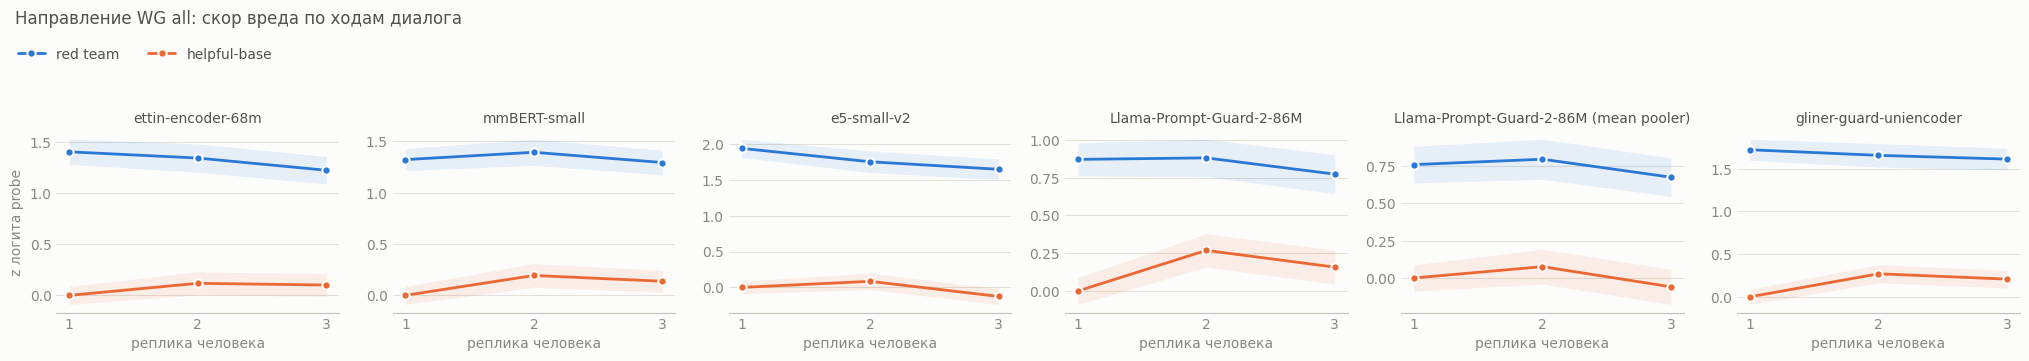

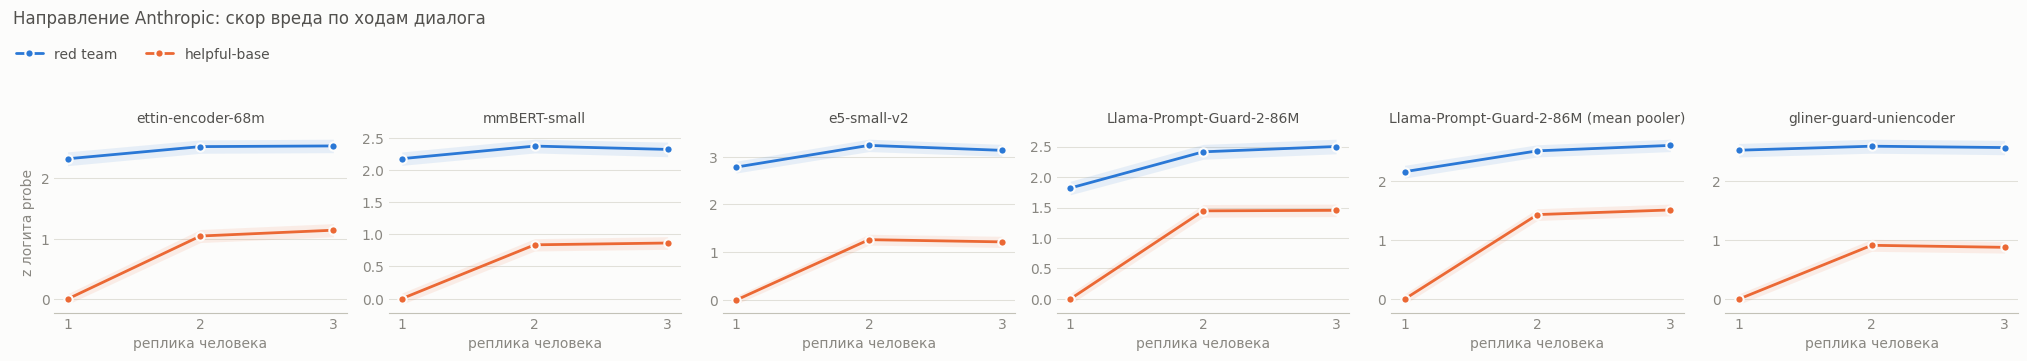

In [20]:
ESCALATION_COLORS = {"red team": "#2a78d6", "helpful-base": "#eb6834"}
SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"


def plot_escalation(source: str):
    positions = np.arange(1, ESCALATION_TURNS + 1)
    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(EMBEDDER_TYPES),
        figsize=(3.4 * len(EMBEDDER_TYPES), 3.6),
        squeeze=False,
        facecolor=SURFACE,
    )

    for axis, model_name in zip(axes[0], EMBEDDER_TYPES):
        probe = HARM_PROBES[model_name][source]
        scores = {
            name: np.stack([
                probe_scores(probe, EMBEDDINGS[model_name][escalation_group(name, f"turn {k}")]).numpy()
                for k in positions
            ])
            for name in ESCALATION_DIALOGS
        }
        # Шкала логитов у каждой модели своя, поэтому всё приводится к первым репликам helpful-base
        reference = scores["helpful-base"][0]
        center, scale = reference.mean(), reference.std()

        for name, name_scores in scores.items():
            z_scores = (name_scores - center) / scale
            mean = z_scores.mean(axis=1)
            half_interval = 1.96 * z_scores.std(axis=1, ddof=1) / np.sqrt(z_scores.shape[1])
            color = ESCALATION_COLORS[name]
            axis.fill_between(positions, mean - half_interval, mean + half_interval, color=color, alpha=0.1, linewidth=0)
            axis.plot(
                positions, mean,
                color=color, linewidth=2, solid_capstyle="round", solid_joinstyle="round",
                marker="o", markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.5,
                label=name,
            )

        axis.set_facecolor(SURFACE)
        axis.set_title(model_name, fontsize=10, color=INK_SECONDARY)
        axis.set_xticks(positions)
        axis.set_xlabel("реплика человека", color=INK_MUTED)
        axis.grid(axis="y", color=GRIDLINE, linewidth=0.75)
        axis.set_axisbelow(True)
        axis.tick_params(colors=INK_MUTED, length=0)
        for side, spine in axis.spines.items():
            spine.set_visible(side == "bottom")
            spine.set_color(BASELINE)

    axes[0, 0].set_ylabel("z логита probe", color=INK_MUTED)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.suptitle(f"Направление {source}: скор вреда по ходам диалога", x=0.01, y=0.99, ha="left", color=INK_SECONDARY)
    figure.legend(
        handles, labels,
        loc="upper left", bbox_to_anchor=(0.005, 0.92), ncols=len(labels),
        frameon=False, labelcolor=INK_SECONDARY,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.84))
    plt.close(figure)
    return figure


for source in SCORE_SOURCES:
    display(plot_escalation(source))